# Testing batdetect2 pipeline features:

## **Working on features relevant to the use of this pipeline on recovered Audiomoth .wav recordings**

## 1) Figuring out our imports:

### a) Below are the imports pertaining to accessing data and metadata

In [8]:
from pathlib import Path
import glob
import exiftool
import suncalc
import soundfile as sf
import re

### b) Below are the imports pertaining to data manipulation

In [1]:
import numpy as np
import pandas as pd
import dask.dataframe as dd

### c) Below are the imports pertaining to data visualization

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

### d) Below are the imports pertaining to the use of the MSDS pipeline

In [3]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer
from cfg import get_config

In [4]:
SEATTLE_LATITUDE = 47.655181
SEATTLE_LONGITUDE = -122.293123

### b) This concatenation is used to plot a location summary of activity
### The below plots generate the cumulative plots found in `output_dir/cumulative_plots` 

In [5]:
METRIC_TAGS = {'CALLRATE':'CR',
               'BOUTTIMEPERCENTAGE':'BTP',
               'ACTIVITYINDEX':'AI'}
COLNAME_TAGS = {'CALLRATE':'callrate',
               'BOUTTIMEPERCENTAGE':'bout_time_percentage',
               'ACTIVITYINDEX':'activity_index'}
PLOT_UPPER_LIM = {'CALLRATE':1e3,
               'BOUTTIMEPERCENTAGE':1e2,
               'ACTIVITYINDEX':1e2}

In [6]:
site = "Central Pond"

field_records = dd.read_csv('../field_records/ubna_202[4|5]*', dtype=str).compute()
tel_field_records = field_records[field_records[' Site ']==f' {site} '].sort_values('Date and Time deployed (local) ')
tel_field_records = tel_field_records[pd.to_datetime(tel_field_records['Date and Time deployed (local) ']) >= dt.datetime(2025,2,1)]
tel_field_records

,Date and Time deployed (local),Date and Time recovered (local),AudioMoth #,SD card #,Site,Latitude,Longitude,Sampling rate (Hz),Gain,Filter,...,OFF (secs),Battery start (V),Battery end (V),Deployer,Scribe,Uploader,Upload folder name,Notes,SD card size (GB),Amount of data recovered (GB)
153,2025-02-10T10:00:00,2025-02-24T11:15:00,Q,033,Central Pond,(LATITUDE),(LONGITUDE),192000,Medium,None,...,300,4.118,3.591,AL,AM,WL,recover-20250224,Ikea Batteries 0:00-24:00 UTC; All new batter...,NaN,NaN
4,2025-02-24T09:47:00,2025-03-03T10:36:00,G,031,Central Pond,(LATITUDE),(LONGITUDE),192000,Medium,None,...,300,4.023,3.198,AL,AM,AK,recover-20250303,9 Ikea Batteries 0:00-24:00 UTC,256,70
9,2025-03-03T09:49:00,2025-03-10T10:34:00,Q,025,Central Pond,(LATITUDE),(LONGITUDE),192000,Medium,None,...,300,4.179,3.770,AL,AM,AL,recover-20250310,6 Ikea Batteries 0:00-24:00 UTC; Q is a 9-bat...,256,116
11,2025-03-10T10:33:00,(DATE-TIME),C,026,Central Pond,(LATITUDE),(LONGITUDE),192000,Medium,None,...,300,4.099,(VOLT-END),AL,AM,(UPLOADER),(RECOVER-DATE),9 Ikea Batteries 0:00-24:00 UTC,256,(AMOUNT-RECOVERED)


In [8]:
# for i, row in tel_field_records.iterrows():
#     cfg=dict()
#     cfg["sd_unit"] = row[' SD card # '].strip()
#     cfg['duration'] = 300
#     cfg["cycle_length"] = 600
#     cfg['recording_start'] = '00:00'
#     cfg['recover_folder'] = row[' Upload folder name '].strip()
#     cfg['recording_end'] = '23:59'
#     cfg['output_dir'] = Path(f'../output_dir/{cfg["recover_folder"]}')
#     if 'recover' in cfg['recover_folder'] and (cfg['output_dir'] / site).exists():
#         cfg['resample_tag'] = "30min"
#         cfg['show_PST'] = False

#         data_params = batdetect2_pipeline.get_params_relevant_to_data(cfg)
#         data_params['site_tag'] = site.split()[0]
#         cfg["csv_filename"] = f"bd2__{data_params['recover_folder']}_{data_params['audiomoth_folder']}"
#         data_params['resample_in_min'] = 30
#         data_params['resample_tag'] = f"{data_params['resample_in_min']}min"
#         data_params['detection_threshold_for_activity'] = 0.35
#         data_params['SNR_threshold_for_activity'] = 3

#         batdetect2_pipeline.construct_activity_arr(cfg, data_params)
#         for group in ['', 'LF', 'HF']:
#             for cfg['METRIC'] in ['CALLRATE', 'BOUTTIMEPERCENTAGE', 'ACTIVITYINDEX']:
#                 cfg['METRIC_TAG'] = METRIC_TAGS[cfg['METRIC']]
#                 cfg['COL_TAG'] = COLNAME_TAGS[cfg['METRIC']]
#                 cfg['UPPER_LIM'] = PLOT_UPPER_LIM[cfg['METRIC']]
#                 data_params['METRIC_TAG'] = cfg['METRIC_TAG']
#                 data_params['METRIC'] = cfg['METRIC']
#                 data_params['UPPER_LIM'] = cfg['UPPER_LIM']
#                 activity_df = batdetect2_pipeline.shape_activity_array_into_grid(cfg, data_params, group)
#                 batdetect2_pipeline.plot_activity_grid(activity_df, data_params, group, save=True)

Searching for files from recover-20250303 and UBNA_031
Will save csv file to ../output_dir/recover-20250303/Central Pond
All files from deployment session good!
CALLRATE 


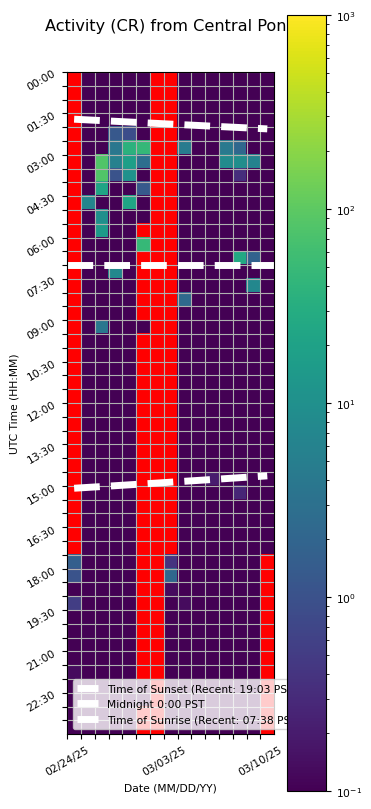

BOUTTIMEPERCENTAGE 


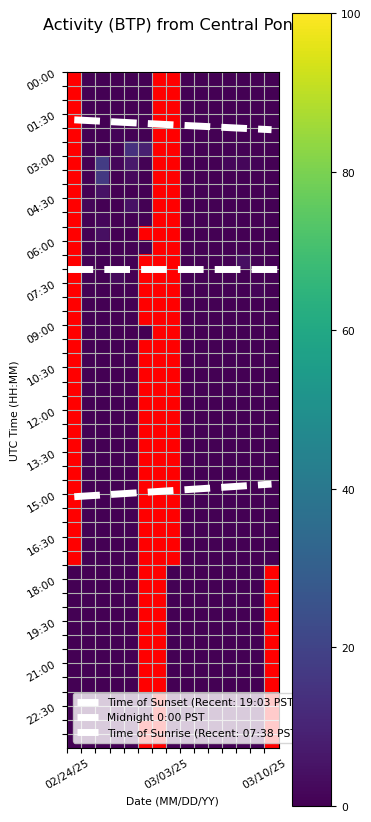

ACTIVITYINDEX 


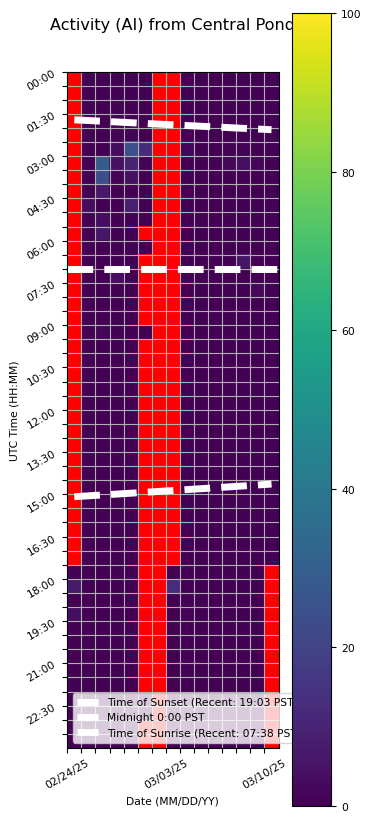

CALLRATE LF


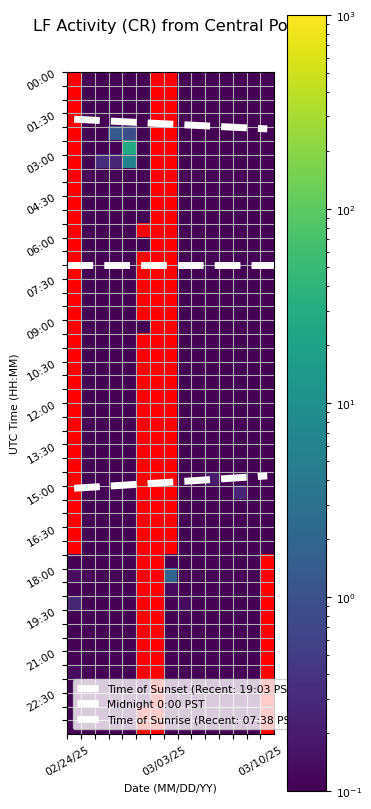

BOUTTIMEPERCENTAGE LF


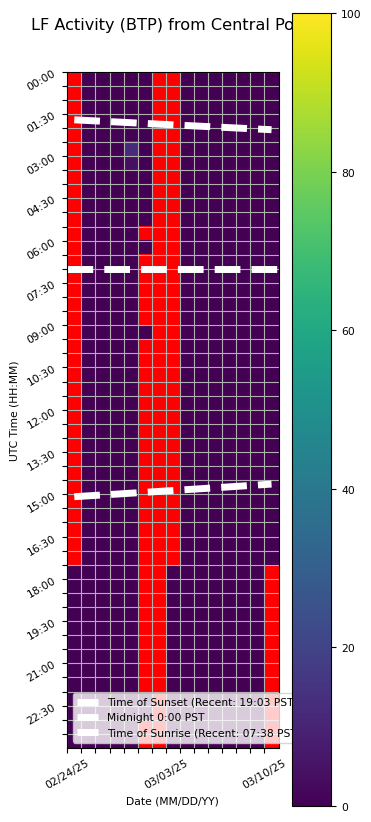

ACTIVITYINDEX LF


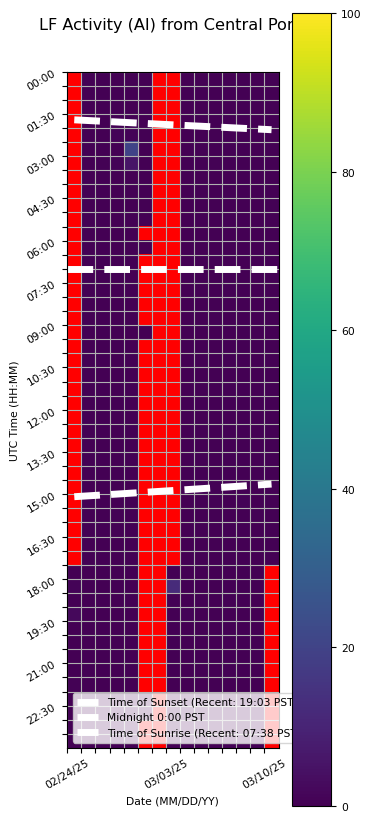

CALLRATE HF


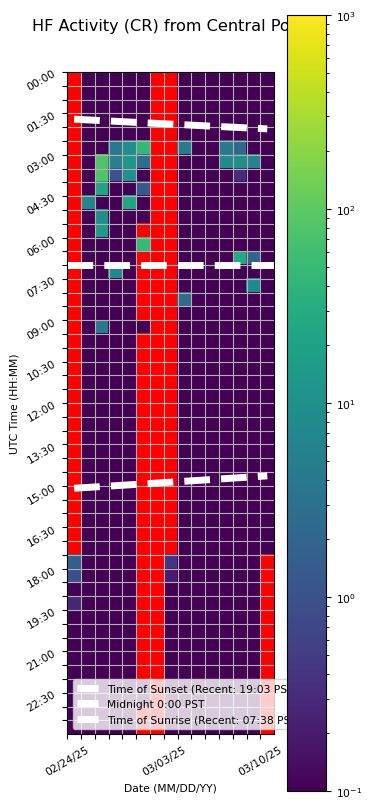

BOUTTIMEPERCENTAGE HF


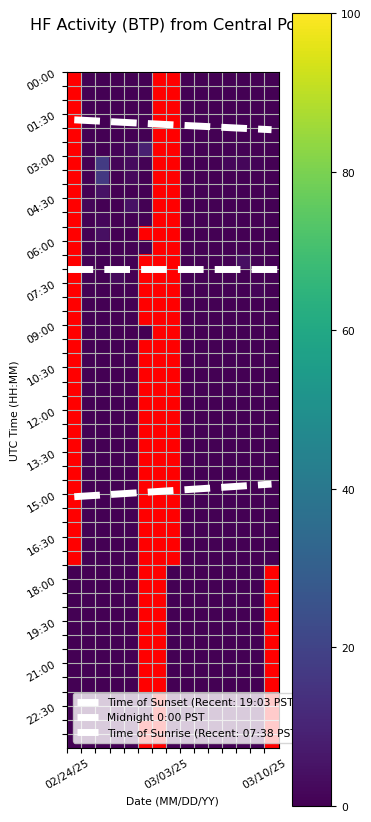

ACTIVITYINDEX HF


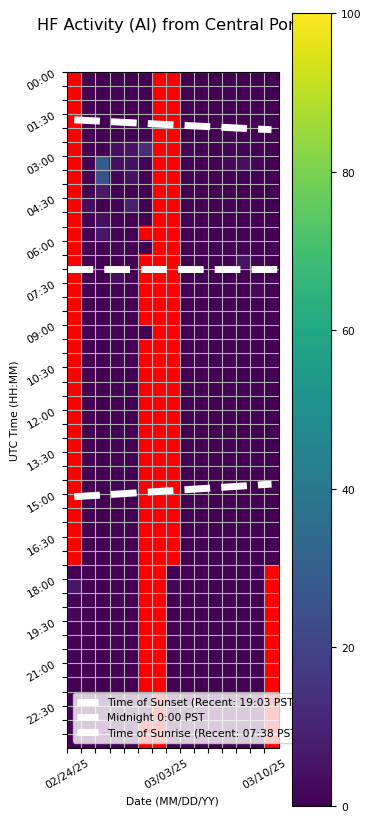

In [10]:
cfg=dict()
cfg["sd_unit"] = '031'
cfg['duration'] = 300
cfg["cycle_length"] = 600
cfg['recording_start'] = '00:00'
cfg['recover_folder'] = 'recover-20250303'
cfg['recording_end'] = '23:59'
cfg['output_dir'] = Path(f'../output_dir/{cfg["recover_folder"]}')
cfg['resample_tag'] = "30min"
cfg['show_PST'] = False

data_params = batdetect2_pipeline.get_params_relevant_to_data(cfg)
data_params['site_tag'] = site.split()[0]
cfg["csv_filename"] = f"bd2__{data_params['recover_folder']}_{data_params['audiomoth_folder']}"
data_params['resample_in_min'] = 30
data_params['resample_tag'] = f"{data_params['resample_in_min']}min"
data_params['detection_threshold_for_activity'] = 0.35
data_params['SNR_threshold_for_activity'] = 3

batdetect2_pipeline.construct_activity_arr(cfg, data_params)
for group in ['', 'LF', 'HF']:
    for cfg['METRIC'] in ['CALLRATE', 'BOUTTIMEPERCENTAGE', 'ACTIVITYINDEX']:
        print(cfg['METRIC'], group)
        cfg['METRIC_TAG'] = METRIC_TAGS[cfg['METRIC']]
        cfg['COL_TAG'] = COLNAME_TAGS[cfg['METRIC']]
        cfg['UPPER_LIM'] = PLOT_UPPER_LIM[cfg['METRIC']]
        data_params['METRIC_TAG'] = cfg['METRIC_TAG']
        data_params['METRIC'] = cfg['METRIC']
        data_params['UPPER_LIM'] = cfg['UPPER_LIM']
                    
        data_params['selection_of_dates'] = 'recover-2025*'
        cumulative_activity_df = batdetect2_pipeline.construct_cumulative_activity(data_params, cfg, group)
        data_params['show_PST'] = False
        batdetect2_pipeline.plot_cumulative_activity(cumulative_activity_df, data_params, group)

In [ ]:
cumulative_activity_df = batdetect2_pipeline.construct_cumulative_activity(data_params, cfg, group)
data_params['show_PST'] = False
batdetect2_pipeline.plot_cumulative_activity(cumulative_activity_df, data_params, group)

In [33]:
new_df = dd.read_csv(f"../output_dir/{data_params['selection_of_dates']}/{data_params['site']}/{cfg['METRIC']}__*.csv", assume_missing=True).compute()
new_df["date_and_time_UTC"] = pd.to_datetime(new_df["date_and_time_UTC"], format="%Y-%m-%d %H:%M:%S%z")
new_df = new_df.set_index('date_and_time_UTC')
new_df = new_df[~new_df.index.duplicated(keep='first')]
new_df

,activity_index,LFactivity_index,HFactivity_index
date_and_time_UTC,,,
2025-02-10 18:10:00+00:00,0.000000,0.000000,0.000000
2025-02-10 18:20:00+00:00,0.000000,0.000000,0.000000
2025-02-10 18:30:00+00:00,28.333333,23.333333,6.666667
2025-02-10 18:40:00+00:00,0.000000,0.000000,0.000000
2025-02-10 18:50:00+00:00,0.000000,0.000000,0.000000
...,...,...,...
2025-03-10 17:00:00+00:00,1.666667,1.666667,0.000000
2025-03-10 17:10:00+00:00,0.000000,0.000000,0.000000
2025-03-10 17:20:00+00:00,0.000000,0.000000,0.000000


In [34]:
new_df[1100:1150]

,activity_index,LFactivity_index,HFactivity_index
date_and_time_UTC,,,
2025-02-18 10:50:00+00:00,0.000000,0.000000,0.0
2025-02-18 11:00:00+00:00,0.000000,0.000000,0.0
2025-02-18 12:00:00+00:00,0.000000,0.000000,0.0
2025-02-18 13:20:00+00:00,0.000000,0.000000,0.0
2025-02-18 15:40:00+00:00,0.000000,0.000000,0.0
2025-02-18 19:50:00+00:00,0.000000,0.000000,0.0
2025-02-18 20:10:00+00:00,0.000000,0.000000,0.0
2025-02-18 21:10:00+00:00,0.000000,0.000000,0.0
2025-02-19 00:20:00+00:00,0.000000,0.000000,0.0


In [35]:
expected_dts = pd.date_range(new_df.iloc[0].name, new_df.iloc[-1].name, freq='10min')

In [36]:
valid_nan_df = new_df.reindex(expected_dts, fill_value=np.NaN).reset_index()
valid_nan_df

,index,activity_index,LFactivity_index,HFactivity_index
0,2025-02-10 18:10:00+00:00,0.000000,0.000000,0.000000
1,2025-02-10 18:20:00+00:00,0.000000,0.000000,0.000000
2,2025-02-10 18:30:00+00:00,28.333333,23.333333,6.666667
3,2025-02-10 18:40:00+00:00,0.000000,0.000000,0.000000
4,2025-02-10 18:50:00+00:00,0.000000,0.000000,0.000000
...,...,...,...,...
4025,2025-03-10 17:00:00+00:00,1.666667,1.666667,0.000000
4026,2025-03-10 17:10:00+00:00,0.000000,0.000000,0.000000
4027,2025-03-10 17:20:00+00:00,0.000000,0.000000,0.000000
4028,2025-03-10 17:30:00+00:00,6.666667,6.666667,0.000000


In [39]:
valid_nan_df[1300:1350]

,index,activity_index,LFactivity_index,HFactivity_index
1300,2025-02-19 18:50:00+00:00,NaN,NaN,NaN
1301,2025-02-19 19:00:00+00:00,NaN,NaN,NaN
1302,2025-02-19 19:10:00+00:00,NaN,NaN,NaN
1303,2025-02-19 19:20:00+00:00,0.0,0.0,0.0
1304,2025-02-19 19:30:00+00:00,NaN,NaN,NaN
1305,2025-02-19 19:40:00+00:00,NaN,NaN,NaN
1306,2025-02-19 19:50:00+00:00,NaN,NaN,NaN
1307,2025-02-19 20:00:00+00:00,NaN,NaN,NaN
1308,2025-02-19 20:10:00+00:00,NaN,NaN,NaN
1309,2025-02-19 20:20:00+00:00,NaN,NaN,NaN


In [44]:
resampled_df = valid_nan_df.resample(data_params["resample_tag"], on="index").mean().between_time(cfg['recording_start'], cfg['recording_end'], inclusive='left').dropna()
resampled_df[350:400]

,activity_index,LFactivity_index,HFactivity_index
index,,,
2025-02-18 01:00:00+00:00,0.000000,0.000000,0.000000
2025-02-18 01:30:00+00:00,0.000000,0.000000,0.000000
2025-02-18 02:00:00+00:00,0.000000,0.000000,0.000000
2025-02-18 02:30:00+00:00,0.000000,0.000000,0.000000
2025-02-18 03:00:00+00:00,0.000000,0.000000,0.000000
2025-02-18 03:30:00+00:00,0.000000,0.000000,0.000000
2025-02-18 04:00:00+00:00,0.000000,0.000000,0.000000
2025-02-18 04:30:00+00:00,0.000000,0.000000,0.000000
2025-02-18 05:00:00+00:00,0.000000,0.000000,0.000000


In [46]:
expected_dts = pd.date_range(resampled_df.iloc[0].name, resampled_df.iloc[-1].name, freq='30min')
expected_dts

DatetimeIndex(['2025-02-10 18:00:00+00:00', '2025-02-10 18:30:00+00:00',
               '2025-02-10 19:00:00+00:00', '2025-02-10 19:30:00+00:00',
               '2025-02-10 20:00:00+00:00', '2025-02-10 20:30:00+00:00',
               '2025-02-10 21:00:00+00:00', '2025-02-10 21:30:00+00:00',
               '2025-02-10 22:00:00+00:00', '2025-02-10 22:30:00+00:00',
               ...
               '2025-03-10 13:00:00+00:00', '2025-03-10 13:30:00+00:00',
               '2025-03-10 14:00:00+00:00', '2025-03-10 14:30:00+00:00',
               '2025-03-10 15:00:00+00:00', '2025-03-10 15:30:00+00:00',
               '2025-03-10 16:00:00+00:00', '2025-03-10 16:30:00+00:00',
               '2025-03-10 17:00:00+00:00', '2025-03-10 17:30:00+00:00'],
              dtype='datetime64[ns, UTC]', length=1344, freq='30T')

In [48]:
valid_resampled_nan_df = resampled_df.reindex(expected_dts, fill_value=np.NaN)
valid_resampled_nan_df[400:450]

,activity_index,LFactivity_index,HFactivity_index
2025-02-19 02:00:00+00:00,NaN,NaN,NaN
2025-02-19 02:30:00+00:00,NaN,NaN,NaN
2025-02-19 03:00:00+00:00,NaN,NaN,NaN
2025-02-19 03:30:00+00:00,NaN,NaN,NaN
2025-02-19 04:00:00+00:00,5.0,0.0,5.0
2025-02-19 04:30:00+00:00,NaN,NaN,NaN
2025-02-19 05:00:00+00:00,NaN,NaN,NaN
2025-02-19 05:30:00+00:00,0.0,0.0,0.0
2025-02-19 06:00:00+00:00,NaN,NaN,NaN
2025-02-19 06:30:00+00:00,NaN,NaN,NaN


In [49]:
valid_resampled_nan_df

,activity_index,LFactivity_index,HFactivity_index
2025-02-10 18:00:00+00:00,0.000000,0.000000,0.000000
2025-02-10 18:30:00+00:00,9.444444,7.777778,2.222222
2025-02-10 19:00:00+00:00,0.000000,0.000000,0.000000
2025-02-10 19:30:00+00:00,0.000000,0.000000,0.000000
2025-02-10 20:00:00+00:00,0.000000,0.000000,0.000000
...,...,...,...
2025-03-10 15:30:00+00:00,0.555556,0.555556,0.000000
2025-03-10 16:00:00+00:00,0.000000,0.000000,0.000000
2025-03-10 16:30:00+00:00,1.666667,1.666667,0.000000
2025-03-10 17:00:00+00:00,0.555556,0.555556,0.000000


In [50]:
activity_datetimes = pd.to_datetime(valid_resampled_nan_df.index.values)
raw_dates = activity_datetimes.date
raw_times = activity_datetimes.strftime("%H:%M")
mask = valid_resampled_nan_df.columns.str.contains(f'{group}.*')

data = list(zip(raw_dates, raw_times, valid_resampled_nan_df[f'{group}{cfg["COL_TAG"]}']))
activity = pd.DataFrame(data, columns=["Date (UTC)", "Time (UTC)", f'{group}{cfg["COL_TAG"]}'])
activity[600:610]

,Date (UTC),Time (UTC),HFactivity_index
600,2025-02-23,06:00,NaN
601,2025-02-23,06:30,NaN
602,2025-02-23,07:00,NaN
603,2025-02-23,07:30,NaN
604,2025-02-23,08:00,NaN
605,2025-02-23,08:30,NaN
606,2025-02-23,09:00,NaN
607,2025-02-23,09:30,NaN
608,2025-02-23,10:00,NaN
609,2025-02-23,10:30,NaN


In [51]:
activity_df = activity.pivot(index="Time (UTC)", columns="Date (UTC)", values=f'{group}{cfg["COL_TAG"]}')
activity_df.columns = pd.to_datetime(activity_df.columns).strftime('%m/%d/%y')
activity_df

Date (UTC),02/10/25,02/11/25,02/12/25,02/13/25,02/14/25,02/15/25,02/16/25,02/17/25,02/18/25,02/19/25,...,03/01/25,03/02/25,03/03/25,03/04/25,03/05/25,03/06/25,03/07/25,03/08/25,03/09/25,03/10/25
Time (UTC),,,,,,,,,,,,,,,,,,,,,
00:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
00:30,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
01:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
01:30,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
02:00,NaN,0.0,0.0,0.0,0.000000,0.000000,2.222222,2.777778,0.0,NaN,...,21.666667,16.666667,33.888889,15.000000,1.111111,0.000000,0.000000,8.333333,0.000000,0.000000
02:30,NaN,0.0,0.0,0.0,0.000000,5.000000,1.666667,1.111111,0.0,NaN,...,84.444444,65.555556,72.222222,50.000000,16.666667,64.444444,73.333333,52.222222,42.777778,0.000000
03:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,NaN,...,50.000000,49.444444,66.666667,40.555556,1.666667,35.555556,40.555556,18.333333,57.777778,0.555556
03:30,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,NaN,...,67.777778,62.777778,70.000000,35.000000,0.000000,28.333333,44.444444,23.888889,53.888889,0.555556
04:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,5.0,...,72.222222,61.666667,27.222222,30.555556,1.111111,37.222222,21.111111,25.555556,63.888889,0.000000


In [52]:
activity_df.iloc[:,10:16]

Date (UTC),02/20/25,02/21/25,02/22/25,02/23/25,02/24/25,02/25/25
Time (UTC),,,,,,
00:00,NaN,NaN,NaN,NaN,NaN,0.000000
00:30,NaN,NaN,NaN,NaN,NaN,0.000000
01:00,NaN,NaN,NaN,NaN,NaN,0.000000
01:30,NaN,NaN,NaN,NaN,NaN,0.000000
02:00,NaN,NaN,NaN,NaN,NaN,2.222222
02:30,NaN,NaN,NaN,NaN,NaN,0.000000
03:00,NaN,NaN,NaN,NaN,NaN,0.000000
03:30,NaN,NaN,NaN,NaN,NaN,0.000000
04:00,NaN,NaN,NaN,NaN,NaN,5.000000


In [28]:
if group!='':
    mask = valid_resampled_nan_df.columns.str.contains(f'{group}.*')
    selected_group = valid_resampled_nan_df.loc[:,mask]
    if selected_group.shape[1]>2:
        middle_col = selected_group.iloc[:,1]
        middle_col.loc[middle_col<=1.0] = 0
    data = list(zip(raw_dates, raw_times, selected_group.sum(axis=1)))
else:
    data = list(zip(raw_dates, raw_times, valid_resampled_nan_df[f'{group}{cfg["COL_TAG"]}']))
activity = pd.DataFrame(data, columns=["Date (UTC)", "Time (UTC)", f'{group}{cfg["COL_TAG"]}'])
activity_df = activity.pivot(index="Time (UTC)", columns="Date (UTC)", values=f'{group}{cfg["COL_TAG"]}')
activity_df.columns = pd.to_datetime(activity_df.columns).strftime('%m/%d/%y')
activity_df

Date (UTC),02/10/25,02/11/25,02/12/25,02/13/25,02/14/25,02/15/25,02/16/25,02/17/25,02/18/25,02/19/25,...,03/01/25,03/02/25,03/03/25,03/04/25,03/05/25,03/06/25,03/07/25,03/08/25,03/09/25,03/10/25
Time (UTC),,,,,,,,,,,,,,,,,,,,,
00:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
00:30,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
01:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
01:30,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
02:00,NaN,0.0,0.0,0.0,0.000000,0.000000,2.222222,2.777778,0.0,0.0,...,21.666667,16.666667,33.888889,15.000000,1.111111,0.000000,0.000000,8.333333,0.000000,0.000000
02:30,NaN,0.0,0.0,0.0,0.000000,5.000000,1.666667,1.111111,0.0,0.0,...,84.444444,65.555556,72.222222,50.000000,16.666667,64.444444,73.333333,52.222222,42.777778,0.000000
03:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,50.000000,49.444444,66.666667,40.555556,1.666667,35.555556,40.555556,18.333333,57.777778,0.555556
03:30,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,67.777778,62.777778,70.000000,35.000000,0.000000,28.333333,44.444444,23.888889,53.888889,0.555556
04:00,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,5.0,...,72.222222,61.666667,27.222222,30.555556,1.111111,37.222222,21.111111,25.555556,63.888889,0.000000


In [29]:
activity_df.iloc[:,10:16]

Date (UTC),02/20/25,02/21/25,02/22/25,02/23/25,02/24/25,02/25/25
Time (UTC),,,,,,
00:00,0.0,0.0,0.0,0.0,0.000000,0.000000
00:30,0.0,0.0,0.0,0.0,0.000000,0.000000
01:00,0.0,0.0,0.0,0.0,0.000000,0.000000
01:30,0.0,0.0,0.0,0.0,0.000000,0.000000
02:00,0.0,0.0,0.0,0.0,0.000000,2.222222
02:30,0.0,0.0,0.0,0.0,0.000000,0.000000
03:00,0.0,0.0,0.0,0.0,0.000000,0.000000
03:30,0.0,0.0,0.0,0.0,0.000000,0.000000
04:00,0.0,0.0,0.0,0.0,0.000000,5.000000


In [ ]:
cum_plots_dir = f'{Path(__file__).parent}/../output_dir/cumulative_plots/'